# Análise de Dados para Machine Learning

Projeto desenvolvido sobre a base da ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis). O objetivo é analisar o comportamento dos preços do **Óleo Diesel S10** nos estados brasileiros e construir um modelo capaz de **identificar semanas de alta volatilidade** de preços.

Pipeline:
1. Carregamento e inspeção inicial
2. Limpeza, remoção de nulos e tipagem
3. Seleção do combustível e período de interesse
4. Análise exploratória (EDA)
5. Engenharia de features e definição do alvo
6. Divisão temporal treino/teste e modelagem
7. Avaliação

## 1. Carregamento dos Dados

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay,
)

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

In [29]:
df = pd.read_excel(
    "../raw/semanal-estados-desde-2013.xlsx",
    skiprows=17,
)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 111723
Colunas: 18


,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2012-12-30,2013-01-05,NORTE,ACRE,ETANOL HIDRATADO,33,R$/l,2.553,0.098,2.42,3.000,0.428,0.038,2.125,0.17,1.6239,2.2744,0.08
1,2012-12-30,2013-01-05,NORDESTE,ALAGOAS,ETANOL HIDRATADO,97,R$/l,2.308,0.066,2.19,2.440,0.27,0.029,2.038,0.061,1.9056,2.2231,0.03
2,2012-12-30,2013-01-05,NORTE,AMAPA,ETANOL HIDRATADO,7,R$/l,2.260,0.045,2.18,2.320,-,0.020,-,-,-,-,-
3,2012-12-30,2013-01-05,NORTE,AMAZONAS,ETANOL HIDRATADO,70,R$/l,2.315,0.080,2.22,2.620,0.189,0.035,2.126,0.045,1.9941,2.2169,0.021
4,2012-12-30,2013-01-05,NORDESTE,BAHIA,ETANOL HIDRATADO,414,R$/l,2.167,0.127,1.85,2.599,0.286,0.059,1.881,0.118,1.62,2.14,0.063


## 2. Limpeza, Remoção de Nulos e Tipagem

A ANP usa `"-"` para representar ausências. Esses valores são convertidos para `NaN` antes de qualquer operação numérica.

O tratamento de nulos é feito em três etapas:

1. **Substituição de `"-"` por `NaN`** — padroniza a representação de ausência.
2. **Remoção de colunas com cobertura insuficiente** — colunas em que mais de 50 % dos registros são nulos não acrescentam informação confiável ao modelo e são descartadas. `MARGEM MÉDIA REVENDA` costuma se enquadrar nesse critério pela base da ANP.
3. **Remoção de linhas sem dados nas colunas-chave** — registros sem `PREÇO MÉDIO REVENDA` ou sem `DATA INICIAL` não podem ser usados em nenhuma etapa do pipeline e são eliminados.

In [30]:
df = df.replace("-", np.nan)

nulos_por_coluna = df.isna().sum().sort_values(ascending=False)
print("Valores ausentes por coluna (top 15):")
display(nulos_por_coluna.head(15))

Valores ausentes por coluna (top 15):


C:\Users\Caio Ladeira\AppData\Local\Temp\ipykernel_44012\1615028162.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


MARGEM MÉDIA REVENDA             54497
COEF DE VARIAÇÃO DISTRIBUIÇÃO    54477
PREÇO MÁXIMO DISTRIBUIÇÃO        54477
PREÇO MÍNIMO DISTRIBUIÇÃO        54477
DESVIO PADRÃO DISTRIBUIÇÃO       54477
PREÇO MÉDIO DISTRIBUIÇÃO         54477
DATA FINAL                           0
COEF DE VARIAÇÃO REVENDA             0
PREÇO MÁXIMO REVENDA                 0
DATA INICIAL                         0
DESVIO PADRÃO REVENDA                0
PREÇO MÉDIO REVENDA                  0
UNIDADE DE MEDIDA                    0
NÚMERO DE POSTOS PESQUISADOS         0
PRODUTO                              0
dtype: int64

In [31]:
# Remover colunas com mais de 50 % de nulos
LIMIAR_NULOS = 0.50
total_linhas = len(df)
colunas_antes = set(df.columns)

colunas_para_dropar = [
    col for col in df.columns
    if df[col].isna().sum() / total_linhas > LIMIAR_NULOS
]

if colunas_para_dropar:
    print(f"Colunas removidas (>{LIMIAR_NULOS:.0%} de nulos): {colunas_para_dropar}")
    df = df.drop(columns=colunas_para_dropar)
else:
    print("Nenhuma coluna ultrapassou o limiar de nulos.")

print(f"Colunas restantes: {df.shape[1]}")

Nenhuma coluna ultrapassou o limiar de nulos.
Colunas restantes: 18


In [32]:
# Remover linhas completamente vazias ou sem as colunas-chave
COLUNAS_CHAVE = ["PREÇO MÉDIO REVENDA", "DATA INICIAL"]
colunas_chave_presentes = [c for c in COLUNAS_CHAVE if c in df.columns]

linhas_antes = len(df)
df = df.dropna(subset=colunas_chave_presentes, how="any")
df = df.dropna(how="all")

print(f"Linhas removidas por nulos nas colunas-chave: {linhas_antes - len(df)}")
print(f"Linhas restantes: {len(df)}")

Linhas removidas por nulos nas colunas-chave: 0
Linhas restantes: 111723


In [33]:
# Conversão de tipos
colunas_numericas = [
    col for col in [
        "PREÇO MÉDIO REVENDA",
        "DESVIO PADRÃO REVENDA",
        "PREÇO MÍNIMO REVENDA",
        "PREÇO MÁXIMO REVENDA",
        "COEF DE VARIAÇÃO REVENDA",
        "PREÇO MÉDIO DISTRIBUIÇÃO",
        "DESVIO PADRÃO DISTRIBUIÇÃO",
        "PREÇO MÍNIMO DISTRIBUIÇÃO",
        "PREÇO MÁXIMO DISTRIBUIÇÃO",
        "COEF DE VARIAÇÃO DISTRIBUIÇÃO",
    ]
    if col in df.columns
]

for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["DATA INICIAL"] = pd.to_datetime(df["DATA INICIAL"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111723 entries, 0 to 111722
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   DATA INICIAL                   111723 non-null  datetime64[ns]
 1   DATA FINAL                     111723 non-null  datetime64[ns]
 2   REGIÃO                         111723 non-null  object        
 3   ESTADO                         111723 non-null  object        
 4   PRODUTO                        111723 non-null  object        
 5   NÚMERO DE POSTOS PESQUISADOS   111723 non-null  int64         
 6   UNIDADE DE MEDIDA              111723 non-null  object        
 7   PREÇO MÉDIO REVENDA            111723 non-null  float64       
 8   DESVIO PADRÃO REVENDA          111723 non-null  float64       
 9   PREÇO MÍNIMO REVENDA           111723 non-null  float64       
 10  PREÇO MÁXIMO REVENDA           111723 non-null  float64       
 11  

## 3. Seleção do Combustível e Período

### Por que Óleo Diesel S10?

O Diesel S10 (baixo teor de enxofre) foi escolhido por ter a maior cobertura histórica na base da ANP, impacto direto na cadeia de transporte e logística brasileira, e variabilidade de preços adequada para um problema de classificação binária.

O período selecionado é **2021–presente**, capturando o ciclo de alta pós-pandemia e o choque de 2022.

In [34]:
print(f"Produtos disponíveis: {df['PRODUTO'].nunique()}")
print(df["PRODUTO"].value_counts())

Produtos disponíveis: 7
PRODUTO
GASOLINA COMUM        18538
OLEO DIESEL S10       18524
GLP                   18509
OLEO DIESEL           18487
ETANOL HIDRATADO      18361
GNV                   11527
GASOLINA ADITIVADA     7777
Name: count, dtype: int64


In [35]:
df_diesel = df[df["PRODUTO"] == "OLEO DIESEL S10"].copy()
print(f"Registros de Diesel S10 (total): {len(df_diesel)}")

Registros de Diesel S10 (total): 18524


In [36]:
df_diesel = df_diesel[
    df_diesel["DATA INICIAL"] >= pd.Timestamp("2021-01-01")
].copy()

print(f"Registros após filtro de data: {len(df_diesel)}")
print(f"Período: {df_diesel['DATA INICIAL'].min().date()} a {df_diesel['DATA INICIAL'].max().date()}")
df_diesel.head()

Registros após filtro de data: 7494
Período: 2021-01-03 a 2026-05-03


,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
62337,2021-01-03,2021-01-09,NORTE,ACRE,OLEO DIESEL S10,27,R$/l,4.590,0.107,4.36,4.850,NaN,0.023,NaN,NaN,NaN,NaN,NaN
62338,2021-01-03,2021-01-09,NORDESTE,ALAGOAS,OLEO DIESEL S10,29,R$/l,3.982,0.121,3.63,4.199,NaN,0.030,NaN,NaN,NaN,NaN,NaN
62339,2021-01-03,2021-01-09,NORTE,AMAPA,OLEO DIESEL S10,13,R$/l,4.290,0.104,4.19,4.540,NaN,0.024,NaN,NaN,NaN,NaN,NaN
62340,2021-01-03,2021-01-09,NORTE,AMAZONAS,OLEO DIESEL S10,48,R$/l,3.800,0.152,3.63,4.190,NaN,0.040,NaN,NaN,NaN,NaN,NaN
62341,2021-01-03,2021-01-09,NORDESTE,BAHIA,OLEO DIESEL S10,101,R$/l,3.704,0.165,3.49,3.999,NaN,0.045,NaN,NaN,NaN,NaN,NaN


## 4. Análise Exploratória de Dados (EDA)

Investigamos a evolução temporal dos preços, a dispersão entre estados e regiões, e os padrões de volatilidade.

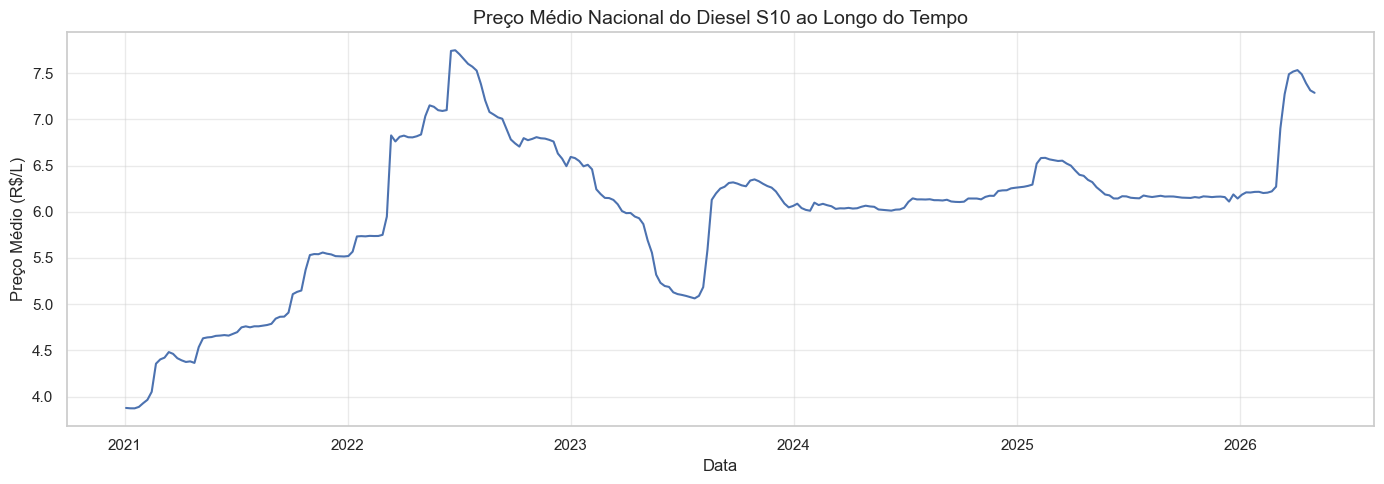

In [37]:
media_tempo = (
    df_diesel
    .groupby("DATA INICIAL")["PREÇO MÉDIO REVENDA"]
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(media_tempo.index, media_tempo.values, linewidth=1.5)
ax.set_title("Preço Médio Nacional do Diesel S10 ao Longo do Tempo", fontsize=14)
ax.set_xlabel("Data")
ax.set_ylabel("Preço Médio (R$/L)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Nota-se uma tendência de alta pronunciada em 2021–2022, influenciada pelo aumento do preço do petróleo e pela variação cambial. A partir de meados de 2022, há uma reversão gradual. Esses eventos geram os picos de volatilidade que o modelo buscará identificar.

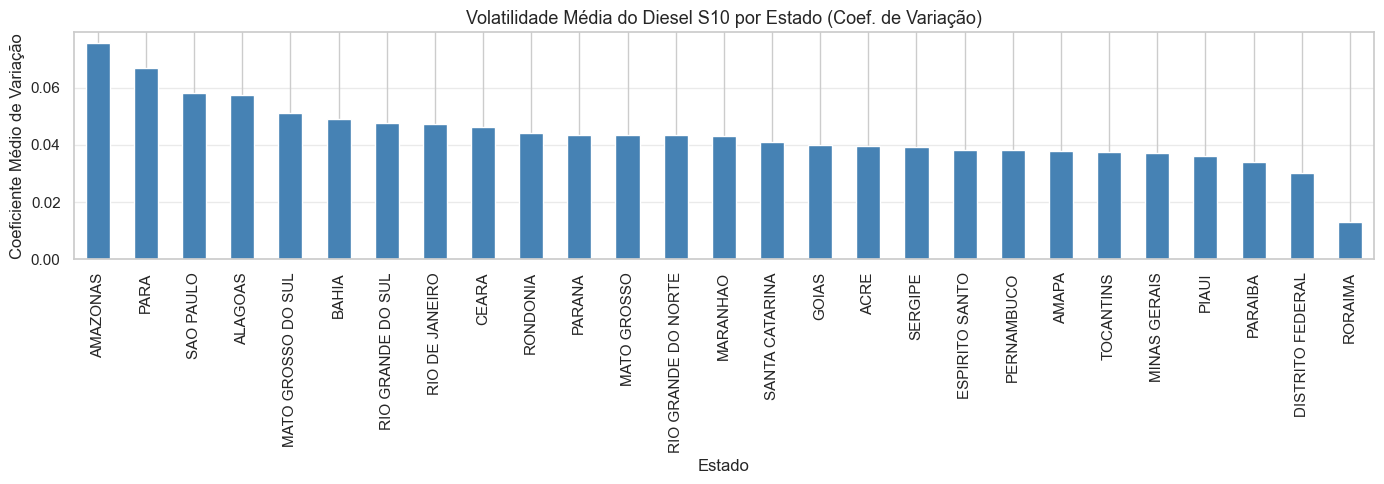

In [38]:
volatilidade_estado = (
    df_diesel
    .groupby("ESTADO")["COEF DE VARIAÇÃO REVENDA"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
volatilidade_estado.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Volatilidade Média do Diesel S10 por Estado (Coef. de Variação)", fontsize=13)
ax.set_xlabel("Estado")
ax.set_ylabel("Coeficiente Médio de Variação")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Estados do Norte (Amazonas, Pará) e do Nordeste tendem a apresentar maior variabilidade, possivelmente por dificuldades logísticas e menor concorrência no varejo. Esse padrão motiva a inclusão do estado como variável de estratificação no modelo.

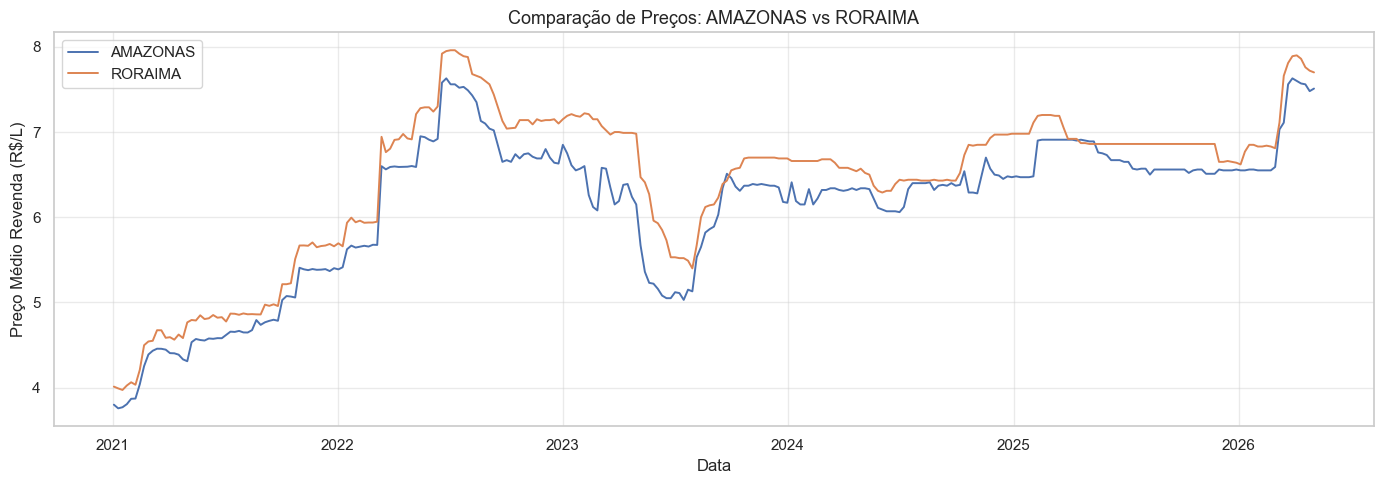

In [39]:
estado_maior_vol = volatilidade_estado.index[0]
estado_menor_vol = volatilidade_estado.index[-1]

estados = [estado_maior_vol, estado_menor_vol]
df_estados = df_diesel[df_diesel["ESTADO"].isin(estados)]

fig, ax = plt.subplots(figsize=(14, 5))
for estado in estados:
    dados = df_estados[df_estados["ESTADO"] == estado].sort_values("DATA INICIAL")
    ax.plot(dados["DATA INICIAL"], dados["PREÇO MÉDIO REVENDA"], label=estado, linewidth=1.4)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_title(f"Comparação de Preços: {estado_maior_vol} vs {estado_menor_vol}", fontsize=13)
ax.set_xlabel("Data")
ax.set_ylabel("Preço Médio Revenda (R$/L)")
plt.tight_layout()
plt.show()

C:\Users\Caio Ladeira\AppData\Local\Temp\ipykernel_44012\1052089673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


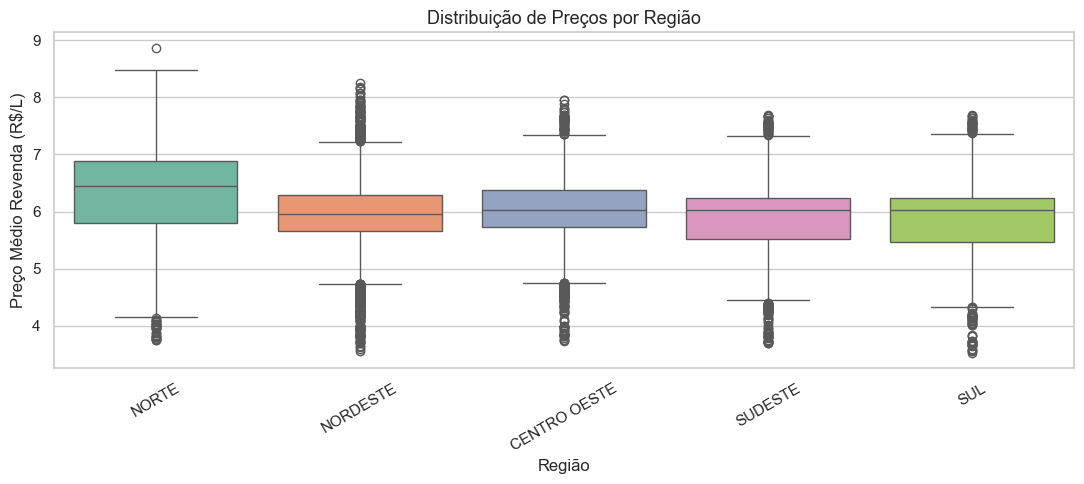

In [40]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df_diesel,
    x="REGIÃO",
    y="PREÇO MÉDIO REVENDA",
    palette="Set2",
    ax=ax,
)
ax.set_title("Distribuição de Preços por Região", fontsize=13)
ax.set_xlabel("Região")
ax.set_ylabel("Preço Médio Revenda (R$/L)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Engenharia de Features e Definição do Alvo

### Variação semanal

A variação percentual é calculada semana a semana dentro de cada estado, evitando que a transição entre o último registro de um estado e o primeiro de outro gere variações espúrias.

In [55]:
df_diesel = df_diesel.sort_values(["ESTADO", "DATA INICIAL"]).reset_index(drop=True)

df_diesel["VARIACAO_SEMANAL"] = (
    df_diesel
    .groupby("ESTADO")["PREÇO MÉDIO REVENDA"]
    .pct_change()
)

df_diesel[["ESTADO", "DATA INICIAL", "PREÇO MÉDIO REVENDA", "VARIACAO_SEMANAL"]].head(10)

,ESTADO,DATA INICIAL,PREÇO MÉDIO REVENDA,VARIACAO_SEMANAL
0,ACRE,2021-01-03,4.590,NaN
1,ACRE,2021-01-10,4.617,0.005882
2,ACRE,2021-01-17,4.681,0.013862
3,ACRE,2021-01-24,4.604,-0.016449
4,ACRE,2021-01-31,4.638,0.007385
5,ACRE,2021-02-07,4.701,0.013583
6,ACRE,2021-02-14,4.806,0.022336
7,ACRE,2021-02-21,5.084,0.057844
8,ACRE,2021-02-28,5.159,0.014752
9,ACRE,2021-03-07,5.182,0.004458


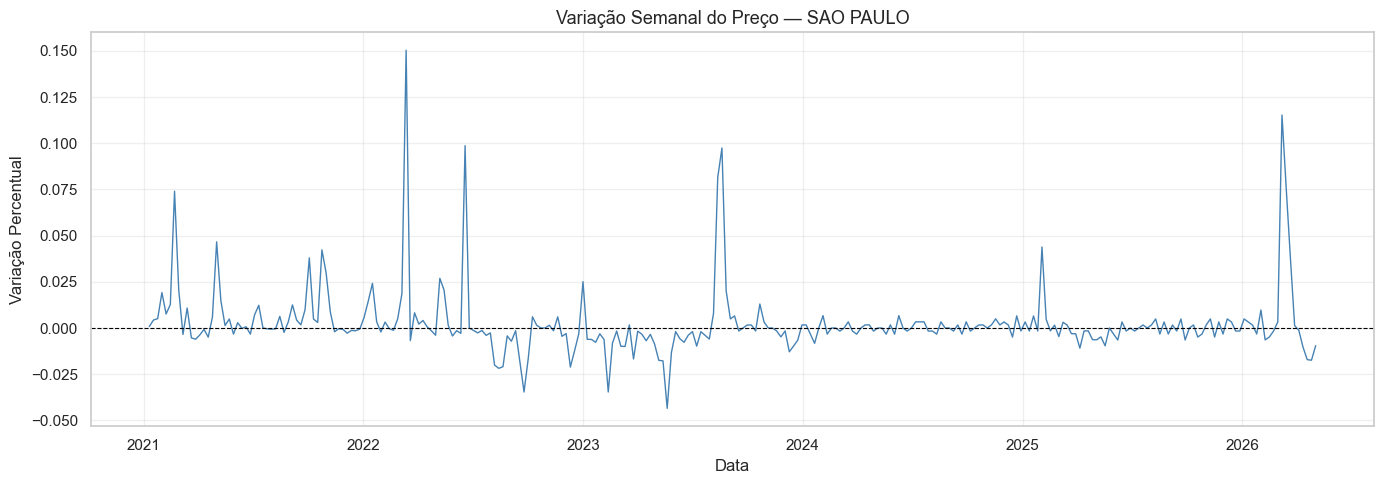

In [42]:
estado_ref = "SAO PAULO"
df_sp = df_diesel[df_diesel["ESTADO"] == estado_ref].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_sp["DATA INICIAL"], df_sp["VARIACAO_SEMANAL"], linewidth=1.0, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Variação Semanal do Preço — {estado_ref}", fontsize=13)
ax.set_xlabel("Data")
ax.set_ylabel("Variação Percentual")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Estatísticas descritivas da variação semanal:


count    7467.000000
mean        0.002506
std         0.021368
min        -0.111380
25%        -0.004975
50%         0.000000
75%         0.004858
max         0.200304
Name: VARIACAO_SEMANAL, dtype: float64

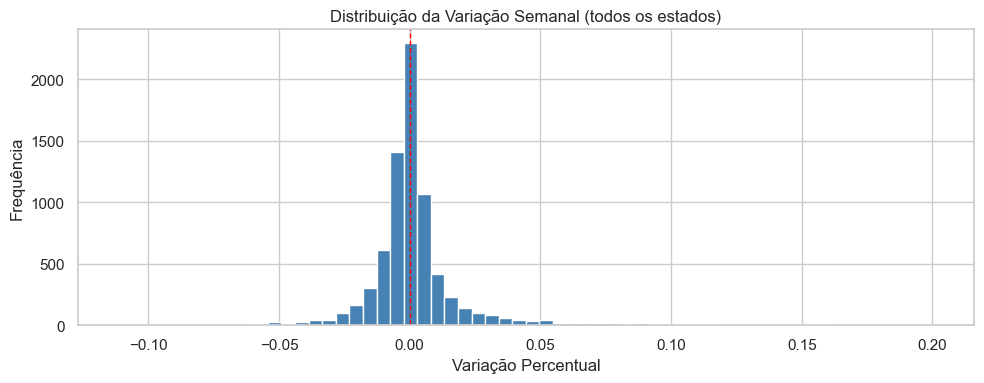

In [43]:
print("Estatísticas descritivas da variação semanal:")
display(df_diesel["VARIACAO_SEMANAL"].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_diesel["VARIACAO_SEMANAL"].dropna(), bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linewidth=1.0, linestyle="--")
ax.set_title("Distribuição da Variação Semanal (todos os estados)", fontsize=12)
ax.set_xlabel("Variação Percentual")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

### Variável alvo: `ALTA_VOLATILIDADE`

O limiar é o **percentil 90** da variação absoluta, calculado exclusivamente sobre o conjunto de treino. Usar o P90 (em vez do P75) garante que apenas semanas genuinamente atípicas sejam classificadas como alta volatilidade, evitando um alvo excessivamente comum.

O cálculo sobre o treino evita data leakage: o modelo não "vê" informação do futuro ao aprender o padrão.

In [44]:
data_corte = df_diesel["DATA INICIAL"].quantile(0.8)
print(f"Data de corte treino/teste: {data_corte.date()}")

mask_train = df_diesel["DATA INICIAL"] <= data_corte
mask_test  = df_diesel["DATA INICIAL"] >  data_corte

print(f"Registros treino: {mask_train.sum()} | Registros teste: {mask_test.sum()}")

Data de corte treino/teste: 2025-04-13
Registros treino: 6014 | Registros teste: 1480


In [45]:
limite_volatilidade = (
    df_diesel.loc[mask_train, "VARIACAO_SEMANAL"]
    .abs()
    .quantile(0.90)
)

print(f"Limiar P90 (calculado no treino): {limite_volatilidade:.4f}")

df_diesel["ALTA_VOLATILIDADE"] = (
    df_diesel["VARIACAO_SEMANAL"].abs() > limite_volatilidade
).astype(int)

print("\nDistribuição do alvo (todos os dados):")
print(df_diesel["ALTA_VOLATILIDADE"].value_counts())
print(f"Taxa de positivos: {df_diesel['ALTA_VOLATILIDADE'].mean():.1%}")

Limiar P90 (calculado no treino): 0.0260

Distribuição do alvo (todos os dados):
ALTA_VOLATILIDADE
0    6792
1     702
Name: count, dtype: int64
Taxa de positivos: 9.4%


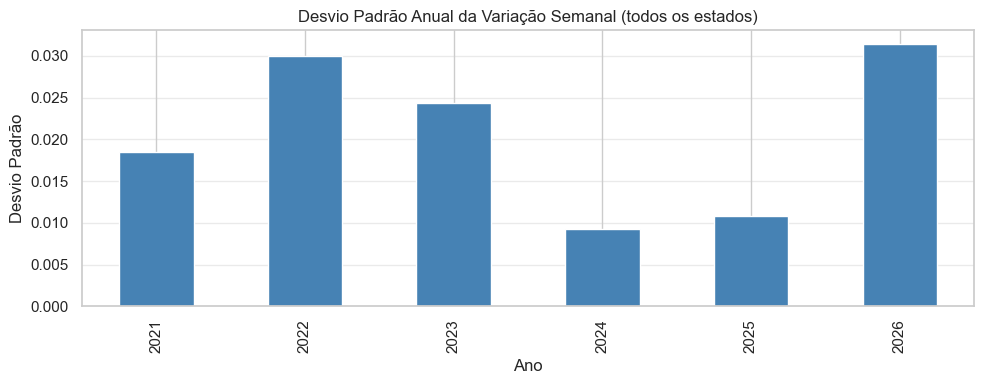

In [46]:
volatilidade_anual = (
    df_diesel
    .groupby(df_diesel["DATA INICIAL"].dt.year)["VARIACAO_SEMANAL"]
    .std()
)

fig, ax = plt.subplots(figsize=(10, 4))
volatilidade_anual.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Desvio Padrão Anual da Variação Semanal (todos os estados)", fontsize=12)
ax.set_xlabel("Ano")
ax.set_ylabel("Desvio Padrão")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### Features do modelo

| Feature | Descrição | Justificativa |
|---|---|---|
| `PREÇO MÉDIO REVENDA` | Nível absoluto do preço | Preços mais altos tendem a ter oscilações maiores |
| `MEDIA_MOVEL_4_SEMANAS` | Média das últimas 4 semanas | Captura tendência de curto prazo |
| `VOLATILIDADE_4_SEMANAS` | Desvio padrão das variações recentes | Indica se o mercado já está agitado |
| `LAG_1_SEMANA` | Variação da semana anterior | Inércia de tendência |
| `LAG_2_SEMANAS` | Variação de 2 semanas atrás | Ciclo de ajuste de preços |
| `MES` | Mês do ano | Sazonalidade |
| `ANO` | Ano | Tendência de longo prazo |

In [47]:
df_diesel["ANO"] = df_diesel["DATA INICIAL"].dt.year
df_diesel["MES"] = df_diesel["DATA INICIAL"].dt.month

df_diesel["MEDIA_MOVEL_4_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["PREÇO MÉDIO REVENDA"]
    .transform(lambda x: x.rolling(4).mean())
)

df_diesel["VOLATILIDADE_4_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .transform(lambda x: x.rolling(4).std())
)

df_diesel["LAG_1_SEMANA"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .shift(1)
)

df_diesel["LAG_2_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .shift(2)
)

df_diesel[
    ["ESTADO", "DATA INICIAL", "PREÇO MÉDIO REVENDA",
     "VARIACAO_SEMANAL", "MEDIA_MOVEL_4_SEMANAS",
     "VOLATILIDADE_4_SEMANAS", "ALTA_VOLATILIDADE"]
].head(10)

,ESTADO,DATA INICIAL,PREÇO MÉDIO REVENDA,VARIACAO_SEMANAL,MEDIA_MOVEL_4_SEMANAS,VOLATILIDADE_4_SEMANAS,ALTA_VOLATILIDADE
0,ACRE,2021-01-03,4.590,NaN,NaN,NaN,0
1,ACRE,2021-01-10,4.617,0.005882,NaN,NaN,0
2,ACRE,2021-01-17,4.681,0.013862,NaN,NaN,0
3,ACRE,2021-01-24,4.604,-0.016449,4.62300,NaN,0
4,ACRE,2021-01-31,4.638,0.007385,4.63500,0.013208,0
5,ACRE,2021-02-07,4.701,0.013583,4.65600,0.014345,0
6,ACRE,2021-02-14,4.806,0.022336,4.68725,0.016615,0
7,ACRE,2021-02-21,5.084,0.057844,4.80725,0.022555,1
8,ACRE,2021-02-28,5.159,0.014752,4.93750,0.020841,0
9,ACRE,2021-03-07,5.182,0.004458,5.05775,0.023186,0


## 6. Divisão Treino/Teste e Modelagem

A divisão é **temporal**: registros anteriores à data de corte formam o treino; os posteriores, o teste. Isso respeita a natureza sequencial dos dados e impede que o modelo aprenda padrões do futuro.

In [48]:
target = "ALTA_VOLATILIDADE"

features = [
    "PREÇO MÉDIO REVENDA",
    "MEDIA_MOVEL_4_SEMANAS",
    "VOLATILIDADE_4_SEMANAS",
    "LAG_1_SEMANA",
    "LAG_2_SEMANAS",
    "MES",
    "ANO",
]

# Os nulos removidos aqui são residuais — surgem exclusivamente das janelas
# móveis (rolling(4)) e dos lags, que por definição não possuem valores nas
# primeiras observações de cada estado. Não representam falha de cobertura
# nos dados originais; são uma consequência esperada do cálculo dessas features.
df_modelo = df_diesel[features + [target, "DATA INICIAL"]].dropna().copy()
print(f"Registros após remover resíduos das janelas móveis: {df_modelo.shape[0]}")

Registros após remover resíduos das janelas móveis: 7386


In [49]:
df_train = df_modelo[df_modelo["DATA INICIAL"] <= data_corte]
df_test  = df_modelo[df_modelo["DATA INICIAL"] >  data_corte]

X_train = df_train[features]
y_train = df_train[target].astype(int)

X_test = df_test[features]
y_test = df_test[target].astype(int)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Taxa positivos treino: {y_train.mean():.1%} | Teste: {y_test.mean():.1%}")

Treino: (5906, 7) | Teste: (1480, 7)
Taxa positivos treino: 10.1% | Teste: 7.0%


In [50]:
print("Distribuição do alvo no TREINO:")
print(y_train.value_counts())
print(f"Taxa positivos treino: {y_train.mean():.1%}")

print("\nDistribuição do alvo no TESTE:")
print(y_test.value_counts())
print(f"Taxa positivos teste: {y_test.mean():.1%}")

Distribuição do alvo no TREINO:
ALTA_VOLATILIDADE
0    5308
1     598
Name: count, dtype: int64
Taxa positivos treino: 10.1%

Distribuição do alvo no TESTE:
ALTA_VOLATILIDADE
0    1377
1     103
Name: count, dtype: int64
Taxa positivos teste: 7.0%


In [51]:
X_train_maj = X_train[y_train == 0]
y_train_maj = y_train[y_train == 0]
X_train_min = X_train[y_train == 1]
y_train_min = y_train[y_train == 1]

X_train_min_up, y_train_min_up = resample(
    X_train_min, y_train_min,
    replace=True,
    n_samples=len(X_train_maj) // 2,
    random_state=42,
)

X_train_bal = pd.concat([X_train_maj, X_train_min_up])
y_train_bal = pd.concat([y_train_maj, y_train_min_up])

print(f"Treino balanceado: {y_train_bal.value_counts().to_dict()}")

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
)

modelo.fit(X_train_bal, y_train_bal)
y_pred = modelo.predict(X_test)

Treino balanceado: {0: 5308, 1: 2654}


## 7. Avaliação do Modelo

Para classificação com classes desbalanceadas, accuracy é uma métrica enganosa — um modelo que prevê sempre "baixa volatilidade" atingiria ~90 % de acurácia sem utilidade prática. As métricas relevantes são:

- **Recall:** proporção de semanas de alta volatilidade corretamente detectadas.
- **Precision:** dos alertas emitidos, quantos eram genuinamente de alta volatilidade.
- **F1-score:** média harmônica entre precision e recall.

In [52]:
print("=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred, target_names=["Baixa Volatilidade", "Alta Volatilidade"]))
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")

=== Relatório de Classificação ===
                    precision    recall  f1-score   support

Baixa Volatilidade       0.97      0.97      0.97      1377
 Alta Volatilidade       0.63      0.62      0.63       103

          accuracy                           0.95      1480
         macro avg       0.80      0.80      0.80      1480
      weighted avg       0.95      0.95      0.95      1480

Acurácia: 94.86%


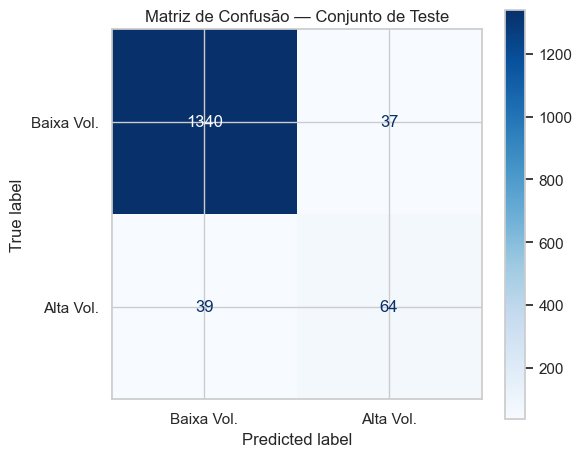

In [53]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Baixa Vol.", "Alta Vol."],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Matriz de Confusão — Conjunto de Teste", fontsize=12)
plt.tight_layout()
plt.show()

Importância das features:


VOLATILIDADE_4_SEMANAS    0.5012
LAG_2_SEMANAS             0.1292
LAG_1_SEMANA              0.1056
MEDIA_MOVEL_4_SEMANAS     0.0858
PREÇO MÉDIO REVENDA       0.0760
MES                       0.0646
ANO                       0.0376
dtype: float64

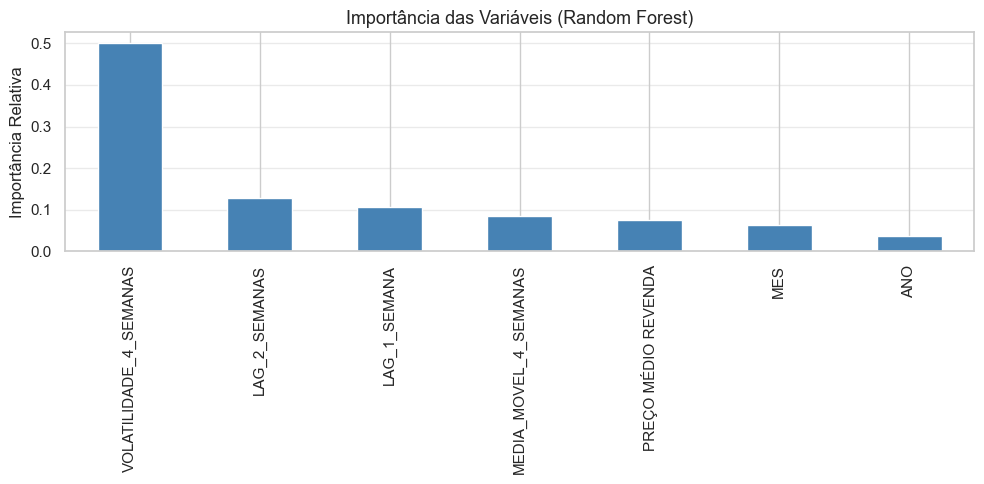

In [54]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=features,
).sort_values(ascending=False)

print("Importância das features:")
display(importancias.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
importancias.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Importância das Variáveis (Random Forest)", fontsize=13)
ax.set_ylabel("Importância Relativa")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()